# MLFlow for Kaggle II - Loan Approval Prediction

In this notebook we will use the Loan Approval dataset to demonstrate how to build a machine learning pipeline using the MLFlow library. We will use the following steps:

1. Data Collection
2. Data Exploration
3. EDA - Exploratory Data Analysis
4. Data Preprocessing
5. Model Selection
6. Model Training
7. Model Evaluation
8. Model Optimization
9. Model Tracking
10. Kaggle Submission


## 1. Data Collection

### Loan Approval Prediction

Go to the [Loan Approval Prediction Competition](https://www.kaggle.com/competitions/playground-series-s4e10/overview). **Join the competition** and accept the terms and conditions.

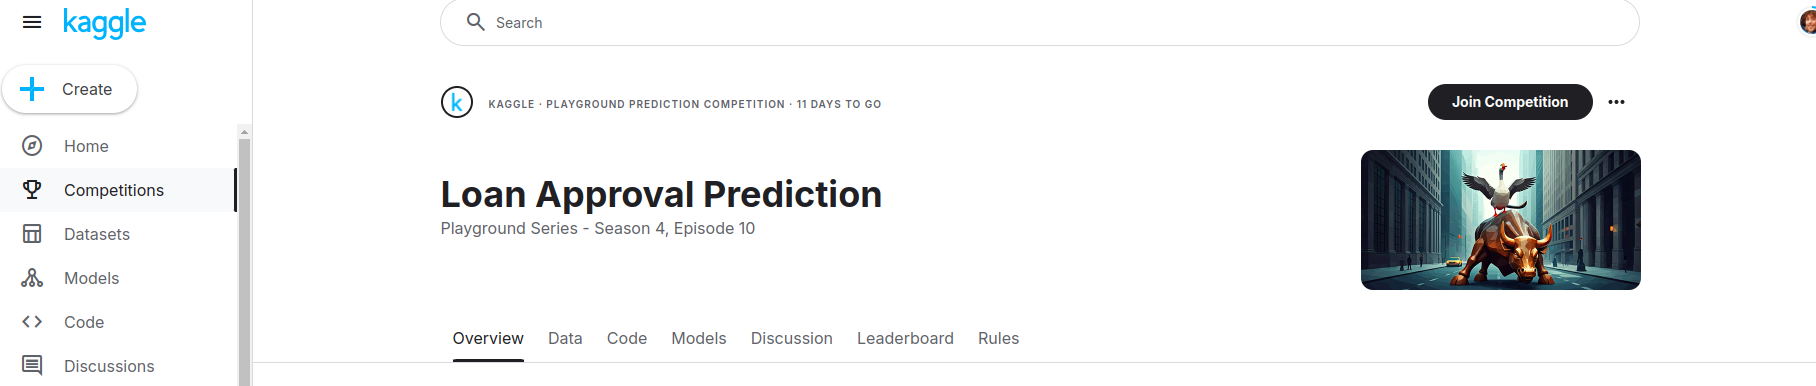

Now **download the data manually** by going to `Data` > `Download Data`

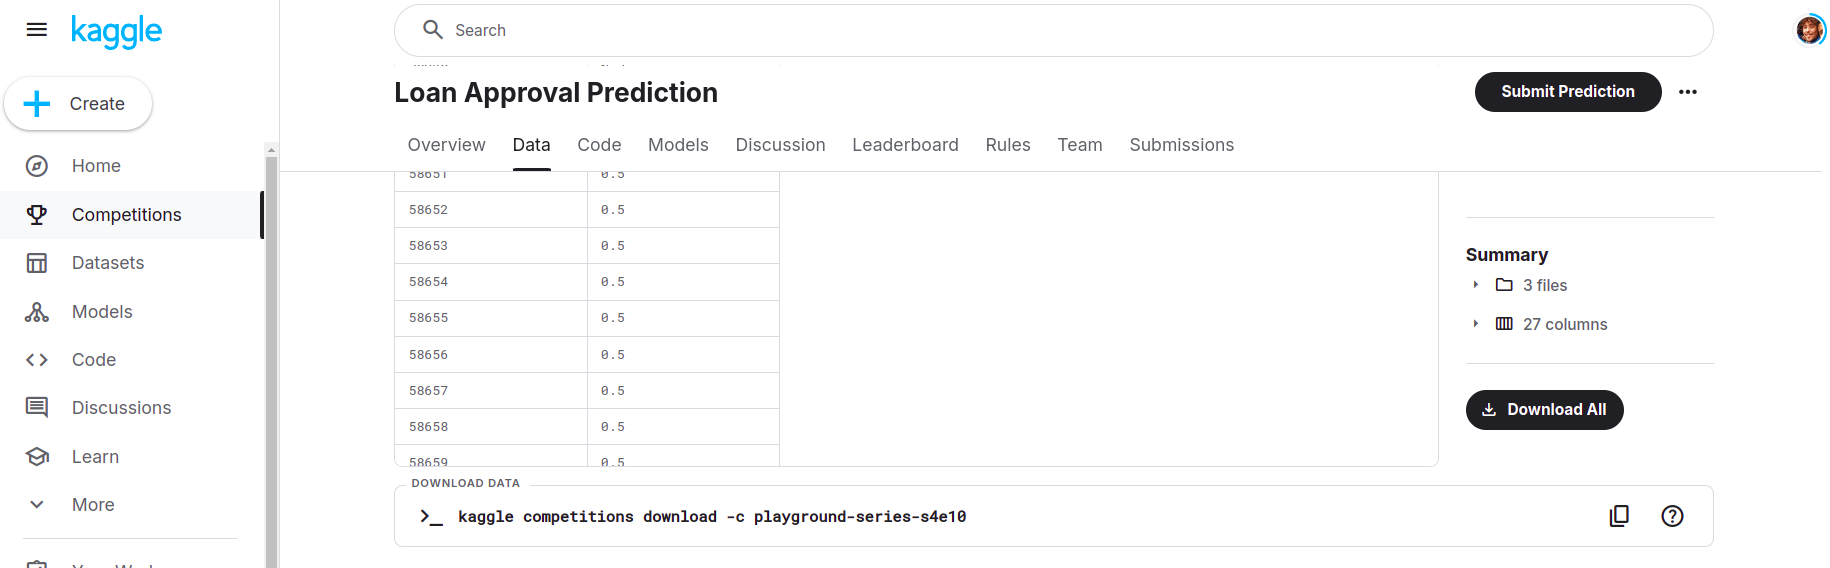

Once we've downloaded the data we are going to save it into `data/loan_prediciton`. We can see there are three files:

- `train.csv`: The training data
- `test.csv`: The test data
- `sample_submission.csv`: The sample submission file

ℹ️ Remember that `test.csv` does not have the target column, we will use it to evaluate our model against the kaggle platform.

## 2. Data Exploration

Let's load the data and take a look at the first few rows.

In [ ]:
import pandas as pd


DATA_FOLDER = "../data/loan_prediction/"
TRAIN_CSV_PATH = DATA_FOLDER + "train.csv"
TEST_CSV_PATH = DATA_FOLDER + "test.csv"


train_df = pd.read_csv(TRAIN_CSV_PATH, index_col='id')
test_df = pd.read_csv(TEST_CSV_PATH, index_col='id')

train_df.head()

**Feature Descriptions**

- person_age: Applicant’s age in years.
- person_income: Annual income of the applicant in USD.
- person_home_ownership: Status of homeownership (e.g., Rent, Own, Mortgage).
- person_emp_length: Length of employment in years.
- loan_intent: Purpose of the loan (e.g., Education, Medical, Personal).
- loan_grade: Risk grade assigned to the loan, assessing the applicant’s creditworthiness.
- loan_amnt: Total loan amount requested by the applicant.
- loan_int_rate: Interest rate associated with the loan.
- loan_percent_income: Percentage of the applicant’s income allocated towards loan repayment.
- cb_person_default_on_file: Indicates if the applicant has a history of default ('Y' for yes, 'N' for no).
- cb_person_cred_hist_length: Length of the applicant’s credit history in years.
- loan_status: The approval status of the loan (1 for rejected, 0 for approved).

In [ ]:
train_df.info()

## 3. EDA - Exploratory Data Analysis

Let's dive into the data and understand it better. In order to do so we import the plotting libraries.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt




We will look at the following:

- Distribution of the loan amount


In [ ]:
ax = sns.displot(train_df, x='loan_amnt', hue='loan_status', kind='kde', fill=True)

- Distribution of the applicant income

In [ ]:
ax = sns.displot(train_df, x='person_income', hue='loan_status', kind='kde', fill=True)
ax.set(xlim=(0, 200000))

- person income vs loan amount

In [ ]:
ax = sns.scatterplot(data=train_df, x='person_income', y='loan_amnt', hue='loan_status')
ax.set(xlim=(0, 200000))

- Loan Percent Income

In [ ]:
ax = sns.displot(train_df, x='loan_percent_income', hue='loan_status', kind='kde', fill=True)

## 4. Data Preprocessing

Remember that we need to preprocess the data before training the model. We will do the following steps:

- Encode the categorical columns
- Scale the numerical columns


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_features = [
    'person_income',
    'person_emp_length',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
]

cat_features = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(), cat_features),
    ]
)

## 5. Model Selection

We will use a Random Forest Classifier to predict the loan approval status.

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier


base_model = RandomForestClassifier(n_estimators=100, random_state=42)

We are going to create a **Pipeline**. This drastically simplifies the process of building a machine learning model because it bundles the preprocessing and the model into a single object.

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('base_model', base_model),
])

## 6. Model Training

Split the data into train and validation sets.

In [ ]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X = train_df.drop(columns=['loan_status'])
y = train_df['loan_status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [ ]:
pipeline.fit(X_train, y_train)

## 7. Model Evaluation

We use the area under the ROC curve to evaluate the model.

In [ ]:
from sklearn.metrics import roc_auc_score


y_pred = pipeline.predict(X_val)
auc_metric = roc_auc_score(y_val, y_pred)

print(f'AUC: {auc_metric:.4f}')

Display the ROC Curve

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax)
ax.set_title('ROC Curve')

## 8. Model Optimization

**At which point should we stop giving loans?**

We should stop giving loans away **the moment that our profit is lower than the loss of giving the loan**. In other words our goal is to minimize the profit sacrificed (FP) while maximizing the loss avoided (TP). At this point we are giving the loans the moment the probability of being a good loan is greater that 0.5. But this may not be the optimal point because the money we lose by giving a loan to a bad applicant is not the same as the money we win by giving a loan to a good applicant when we are 50% sure about our choice.

```plaintext
objective = Maximize(Amount of money we lose by TP - Amount of money we win by FP)

First we compute the probabilities of being correctly predicting a bad loan (true positive):

In [ ]:
y_probs = pipeline.predict_proba(X_val)
y_tp_probs = y_probs[:, 1]  # 1 == bad loan

Then we compute the False Positives Ratio (FPR)  and the True Positives Ratio (TPR) for each threshold.

In [ ]:
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(y_val, y_tp_probs)

Finally we compute the optimal point by maximizing the objective function: maximizing the difference between the True Positives and the False Positives.

In [ ]:
import numpy as np


optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

We compare the AUC when we use the threshold of 0.5 (default).

In [ ]:
average_idx = len(thresholds) // 2
average_threshold = thresholds[average_idx]
fpr_average = fpr[average_idx]
tpr_average = tpr[average_idx]

print(f'Average threshold: {average_threshold:.4f}')
print(f'FPR: {fpr_average:.4f}')
print(f'TPR: {tpr_average:.4f}')

Plot the AUC for the optimal threshold and the default threshold.

In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(pipeline, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')

# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.2f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

Add this tunning step to the pipeline.

In [ ]:
from sklearn.model_selection import TunedThresholdClassifierCV


model = TunedThresholdClassifierCV(pipeline, scoring="roc_auc")

Train the model again with the new pipeline.

In [ ]:
model.fit(X_train, y_train)

Evaluate the model

In [ ]:
from sklearn.metrics import roc_auc_score


y_pred = model.predict(X_val)
auc_metric = roc_auc_score(y_val, y_pred)

print(f'AUC: {auc_metric:.4f}')

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve


y_tp_probs = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_tp_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = model.best_threshold_
fpr_optimal = fpr[optimal_idx]
tpr_optimal = tpr[optimal_idx]

print(f'Optimal threshold: {optimal_threshold:.4f}')
print(f'FPR: {fpr_optimal:.4f}')
print(f'TPR: {tpr_optimal:.4f}')

Plot the ROC curve and the optimal threshold

In [ ]:
# Display the ROC Curve
fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax)
ax.set_title('Optimal Threshold for ROC Curve')


# add optimal point coordinates
ax.axvline(fpr_optimal, color='g', linestyle='--')
ax.axhline(tpr_optimal, color='g', linestyle='--')
ax.scatter(fpr_optimal, tpr_optimal, color='green')  # Añadir el punto
ax.text(fpr_optimal, tpr_optimal, f'Optimal Threshold: {optimal_threshold:.3f}', color='green')

# add average point coordinates
ax.axvline(fpr_average, color='r', linestyle='--')
ax.axhline(tpr_average, color='r', linestyle='--')
ax.scatter(fpr_average, tpr_average, color='red')  # Añadir el punto
ax.text(fpr_average, tpr_average, f'Average Threshold: {average_threshold:.2f}', color='red')

### Generate submission file

Looking at the `submission_sample.csv` file we see that it hmut have two columns: `id` and `loan_status`. The `id` column must have the same values as the test set and the `loan_status` column must have the predictions.

In [ ]:
# Save the CSV to be submitted to a file
SUBMISSION_CSV_PATH = DATA_FOLDER + 'submission.csv'

# obtain the predictions
y_test_pred = model.predict(test_df)


# prepare the data to be submitted
ids_column = test_df.index
submission_data = {
    "id": ids_column,
    "loan_status": y_test_pred
}

# save it to a CSV file
submission_df = pd.DataFrame(submission_data)
submission_df.to_csv(SUBMISSION_CSV_PATH, index=False)
submission_df.head()

## 9. Model Tracking

Once we have trained the model we can use the MLFlow library to track the model performance. We can log the AUC, the metrics, the submission file...

### Connect to MLFlow

In [ ]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("loan_prediction")

### Submit to MLFlow

In [ ]:
with mlflow.start_run():

    mlflow.set_tag("model", model.__class__.__name__)

    mlflow.log_metric("auc", auc_metric)
    mlflow.log_metric("optimal_threshold", optimal_threshold)
    mlflow.log_metric("fpr_optimal", fpr_optimal)
    mlflow.log_metric("tpr_optimal", tpr_optimal)
    mlflow.log_metric("average_threshold", average_threshold)
    mlflow.log_metric("fpr_average", fpr_average)
    mlflow.log_metric("tpr_average", tpr_average)

    mlflow.sklearn.log_model(
        model,
        name="model",
        skops_trusted_types=[
            "sklearn.metrics._ranking.roc_auc_score",
            "sklearn.metrics._scorer._CurveScorer",
            "sklearn.metrics._scorer._Scorer",
            "sklearn.tree._tree.Tree",
            "sklearn.utils._metadata_requests.MetadataRequest",
            "sklearn.utils._metadata_requests.MethodMetadataRequest",
        ],
    )

    mlflow.log_artifact(SUBMISSION_CSV_PATH)

In [ ]:
import mlflow

run_id = "98f55631a65a4debbe89554df326f102"

artifacts = mlflow.MlflowClient().list_artifacts(run_id)

for artifact in artifacts:
    print(artifact.path)

In [ ]:
local_path = mlflow.artifacts.download_artifacts(
    run_id="98f55631a65a4debbe89554df326f102",
    artifact_path="submission.csv"
)

print(local_path)

In [ ]:
import pandas as pd

submission = pd.read_csv(local_path)

print(submission.head())
print(submission.shape)
print(submission.columns)



## 10. Kaggle Submission


Finally we can submit the predictions to the kaggle platfrom. To do so we are going to retrieve the submission CSV from the best MLFlow run and submit it to the kaggle platform. You could upload the results manually by going to the kaggle website and clicking on `Submit Predictions`. You can then upload the file and submit it. Or you can use the kaggle API to submit the file:

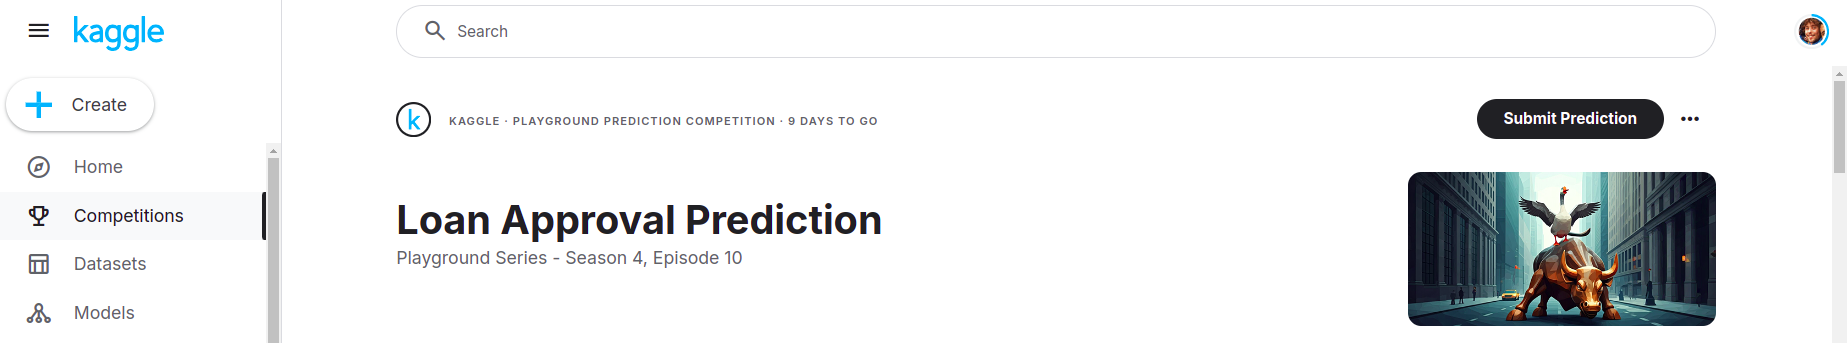

In [ ]:
!kaggle competitions submit \
    -c playground-series-s4e10 \
    -f "{local_path}" \
    -m "Submission from MLflow run 98f55631"

### 🎉 My Submission!:

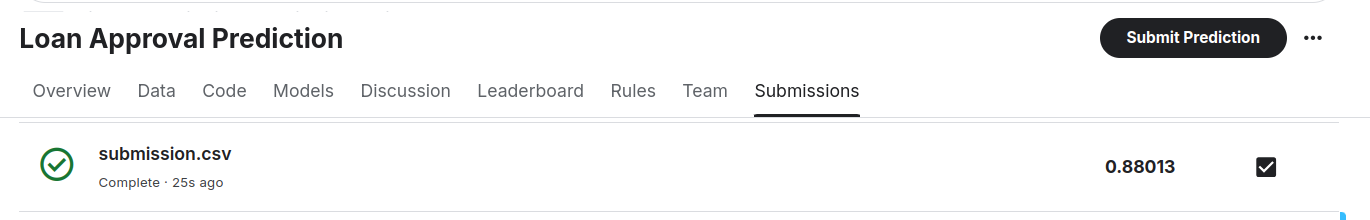

In [ ]:
!kaggle competitions submissions -c playground-series-s4e10

## 11. Model Deployment with Docker and MLflow

The trained model was deployed as a REST API using Docker and MLflow.

The deployment architecture is:

MLflow Tracking Server → Docker Container → FastAPI → `/predict` endpoint

The Docker container retrieves the model registered in MLflow using the `MODEL_URI` environment variable. The API exposes a `/predict` endpoint that receives a loan application as JSON and returns the predicted loan status.

For the local deployment, MLflow runs on port `5001` and the FastAPI application runs inside the Docker container on port `8000`.

### 11.1. Build the Docker Image

The Docker image packages the FastAPI application together with all the Python dependencies required to serve the MLflow model.

The image is built from the `Dockerfile` located in the project root.

In [ ]:
import os

os.environ["PATH"] = "/Users/fabianrmro/.docker/bin:" + os.environ["PATH"]

!docker build -t loan-approval-api ..

In [ ]:
import os
print(os.getcwd())

### 11.2. Run the Docker Container

The Docker container exposes the FastAPI application on port `8000`.

The application connects to the MLflow Tracking Server running on the host machine through `host.docker.internal`.

The `MODEL_URI` identifies the model logged in MLflow that will be loaded by the API.

In [ ]:
import os
import shutil

docker_path = "/Users/fabianrmro/.docker/bin"

if docker_path not in os.environ["PATH"].split(":"):
    os.environ["PATH"] = docker_path + ":" + os.environ["PATH"]

print("Docker:", shutil.which("docker"))

In [ ]:
!docker run --rm -d -p 8000:8000 \
    -e MLFLOW_TRACKING_URI=http://host.docker.internal:5001 \
    -e MODEL_URI=models:/m-5f6d82857fa142349e24023bfc55b5e2 \
    loan-approval-api

In [ ]:
response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=sample_application,
)

print("Status code:", response.status_code)
print("Prediction:", response.json())

### 11.3. Verify the API

The API exposes a root endpoint that can be used to verify that the FastAPI application is running correctly inside the Docker container.

In [ ]:
import requests

health_response = requests.get("http://127.0.0.1:8000/")

print("Status code:", health_response.status_code)
print("Response:", health_response.json())

### 11.4. Prediction Using the Deployed Model

The `/predict` endpoint accepts the same features used by the trained model.

The following example sends a loan application to the deployed API and retrieves the model prediction through an HTTP request.

In [ ]:
sample_application = {
    "person_age": 30,
    "person_income": 50000,
    "person_home_ownership": "RENT",
    "person_emp_length": 5,
    "loan_intent": "PERSONAL",
    "loan_grade": "B",
    "loan_amnt": 10000,
    "loan_int_rate": 10.5,
    "loan_percent_income": 0.20,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 8,
}

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=sample_application,
)

print("Status code:", response.status_code)
print("Prediction:", response.json())

### 11.5. Prediction Interpretation

The API returned a prediction of `0`.

In the original dataset, the `loan_status` target is encoded as:

- `0`: loan approved
- `1`: loan rejected

Therefore, for this example application, the deployed model predicts an approved loan.

This prediction is generated by the model served through the Docker container and retrieved from MLflow.